In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from AutomatedCellAnalysis.displaydata import displaydata
import tkinter as tk
from tkinter import filedialog
import matplotlib.pyplot as plt

In [43]:
ROOT = tk.Tk()
ROOT.withdraw() #closes the tkinter window again. just a cleanup
ROOT.attributes('-topmost', True)
# here we enter the disered file
users_path = filedialog.askopenfilename(title="Choose a single all_results fit file", filetype=(('csv files', '*.csv'),("all files", "*.*")))
users_path = Path(users_path)
all_data = pd.read_csv(users_path)
#all_data2 = pd.read_csv(my_csv2)
#all_data = pd.concat([all_data1,all_data2])
print(users_path)

C:\Users\thinkBookUser\Desktop\Screening_Data_Analyzed\2020\02\06\caged\results\all_results.csv


In [44]:
# this loop recalculates and replaces all mean initial intensities within each unique wells to 8-bit format 
all_data = all_data.replace([np.inf, -np.inf], np.nan)
wells = all_data.well_ID.unique()
i=0
norm_factor = 256
for i in range(len(wells)):
    maxint=(np.max(all_data[all_data['well_ID'] == wells[i]].Mean_init_int))
    for idx, row in all_data[all_data['well_ID'] == wells[i]].iterrows():
        all_data.loc[idx, 'Mean_init_int256'] = all_data.loc[idx, 'Mean_init_int']/maxint*norm_factor
    i+=1
all_data.head(10)
#all_data.to_csv(Path(users_path.parent, "all_results_256.csv")) #<<<<<<< If you want to save the normalised version for using it later

,Unnamed: 0,start(ns),range(ns),breakdown_time(s),midpoint(s),start tau(ns),e_start,e_range,e_breakdown_time,e_midpoint,RMSD,MAPE,error,condition,frameinterval(s),well_ID,ROI_nr,Mean_init_int,ROI_pix,Mean_init_int256
0,0,3.173204,-0.552305,59.588152,51.909255,2.597667,0.078135,0.090782,11.667100,4.303271,0.024980,0.642292,0.0,Untransfected_cells,1.973446,E03,1.0,164.570000,40.0,61.166071
1,1,3.110889,-0.564977,25.642061,49.722490,2.537558,0.071131,0.077627,7.169713,2.411514,0.066637,1.913295,128.0,Untransfected_cells,1.973446,E03,2.0,24.616129,31.0,9.149127
2,2,2.985813,-0.430478,18.492354,56.930956,2.585128,0.033238,0.039894,5.909719,1.698507,0.070132,2.191985,128.0,Untransfected_cells,1.973446,E03,3.0,17.652000,25.0,6.560755
3,3,3.157603,-0.489426,37.536209,56.363895,2.648010,0.043486,0.051794,7.473563,2.248525,0.040122,1.193777,0.0,Untransfected_cells,1.973446,E03,4.0,60.264286,28.0,22.398551
4,4,3.000124,-0.511067,21.492825,52.205548,2.480381,0.068653,0.077269,8.660894,2.616549,0.096800,2.944002,128.0,Untransfected_cells,1.973446,E03,5.0,18.294444,36.0,6.799534
5,5,3.114801,-0.516245,30.433875,51.301628,2.578942,0.053366,0.059128,6.515852,2.208556,0.045633,1.422771,0.0,Untransfected_cells,1.973446,E03,6.0,57.258333,36.0,21.281323
6,6,3.182412,-0.558062,37.767927,58.503469,2.609391,0.022262,0.027533,3.706907,1.047841,0.023311,0.670862,0.0,Untransfected_cells,1.973446,E03,7.0,97.892308,52.0,36.383836
7,7,3.169329,-0.585440,34.275057,56.066292,2.574724,0.022529,0.026612,3.136533,0.943284,0.023271,0.682349,0.0,Untransfected_cells,1.973446,E03,8.0,105.368182,66.0,39.162409
8,8,0.684475,-0.690018,4.000000,50.181757,0.000000,0.245548,0.280875,12.397329,3.720563,0.662880,NaN,408.0,Untransfected_cells,1.973446,E03,9.0,NaN,51.0,NaN
9,9,3.056798,-0.538593,19.003613,48.913416,2.515710,0.027701,0.030223,2.765955,0.863262,0.034578,1.056951,128.0,Untransfected_cells,1.973446,E03,10.0,39.980263,76.0,14.859547


In [45]:
fit_noerrors = all_data[all_data['error']==0] # <<<<<<< the data that passed all hurdles!
fit_hasdarkframe = all_data[all_data['error']==8]  # <<<<<<< the data that was corrected for "dark frame", but otherwise passed all hurdles!
errorfree_data = pd.concat([fit_noerrors,fit_hasdarkframe])  # <<<<<<< We only plot the errorfree data!

first_bin = errorfree_data[(errorfree_data.Mean_init_int256 >= 1) & (errorfree_data.Mean_init_int256 < 256*0.25)]
second_bin = errorfree_data[(errorfree_data.Mean_init_int256 > 256*0.25) & (errorfree_data.Mean_init_int256 < 256*0.5)]
third_bin = errorfree_data[(errorfree_data.Mean_init_int256 > 256*0.5) & (errorfree_data.Mean_init_int256 < 256*0.75)]
fourth_bin = errorfree_data[(errorfree_data.Mean_init_int256 >= 256*0.75)]
low90p_bin = errorfree_data[(errorfree_data.Mean_init_int256 > 1) & (errorfree_data.Mean_init_int256 < 256*0.9)]
high10p_bin = errorfree_data[errorfree_data.Mean_init_int256 >= 256*0.9]
high50p_bin = errorfree_data[errorfree_data.Mean_init_int256 >= 256/2]
low50p_bin = errorfree_data[errorfree_data.Mean_init_int256 < 256/2]
low10p_bin = errorfree_data[(errorfree_data.Mean_init_int256 >= 1) & (errorfree_data.Mean_init_int256 < 256*0.1)]
custom10_20p_bin = errorfree_data[(errorfree_data.Mean_init_int256 > 256*0.1) & (errorfree_data.Mean_init_int256 < 256*0.2)]
bin_above_mean = errorfree_data[(errorfree_data.Mean_init_int256 > np.mean(errorfree_data.Mean_init_int256))]
bin_below_mean = errorfree_data[(errorfree_data.Mean_init_int256 < np.mean(errorfree_data.Mean_init_int256))]
all_bins = errorfree_data

print(len(fit_hasdarkframe), 'ROIs had a dark frame in them, but otherwise no errors (and these data were cured and are now included in plots):')
print('--------------------------------')
print('All_bins (upto 100%) shape:     ', all_bins.shape)
print('--------------------------------')
print('First_bin (upto 25%) shape:     ', first_bin.shape)
print('Second_bin (25-50%) shape:      ', second_bin.shape)
print('Third_bin (upto 50-75%) shape:  ', third_bin.shape)
print('Fourth_bin (upto 75-100%) shape:', fourth_bin.shape)
print('--------------------------------')
print('Lowest90%_bin shape:            ', low90p_bin.shape)
print('Highest10%_bin shape:           ', high10p_bin.shape)
print('--------------------------------')
print('Lowest50%_bin shape:            ', low50p_bin.shape)
print('Highest50%_bin shape:           ', high50p_bin.shape)
print('--------------------------------')
print('Lowest10%_bin shape:            ', low10p_bin.shape)
print('Custom_bin (10-20%)_bin shape:  ', custom10_20p_bin.shape)
print('--------------------------------')
print('bin_above_mean shape:        ', bin_above_mean.shape)
print('bin_below_mean shape:        ', bin_below_mean.shape)
print('--------------------------------')

print(users_path)

0 ROIs had a dark frame in them, but otherwise no errors (and these data were cured and are now included in plots):
--------------------------------
All_bins (upto 100%) shape:      (7187, 20)
--------------------------------
First_bin (upto 25%) shape:      (4570, 20)
Second_bin (25-50%) shape:       (2162, 20)
Third_bin (upto 50-75%) shape:   (386, 20)
Fourth_bin (upto 75-100%) shape: (69, 20)
--------------------------------
Lowest90%_bin shape:             (7165, 20)
Highest10%_bin shape:            (22, 20)
--------------------------------
Lowest50%_bin shape:             (6732, 20)
Highest50%_bin shape:            (455, 20)
--------------------------------
Lowest10%_bin shape:             (1109, 20)
Custom_bin (10-20%)_bin shape:   (2603, 20)
--------------------------------
bin_above_mean shape:         (2901, 20)
bin_below_mean shape:         (4286, 20)
--------------------------------
C:\Users\thinkBookUser\Desktop\Screening_Data_Analyzed\2020\02\06\caged\results\all_results.c

C:\Users\thinkBookUser\Desktop\Screening_Data_Analyzed\2020\02\06\caged\results\all_results.csv


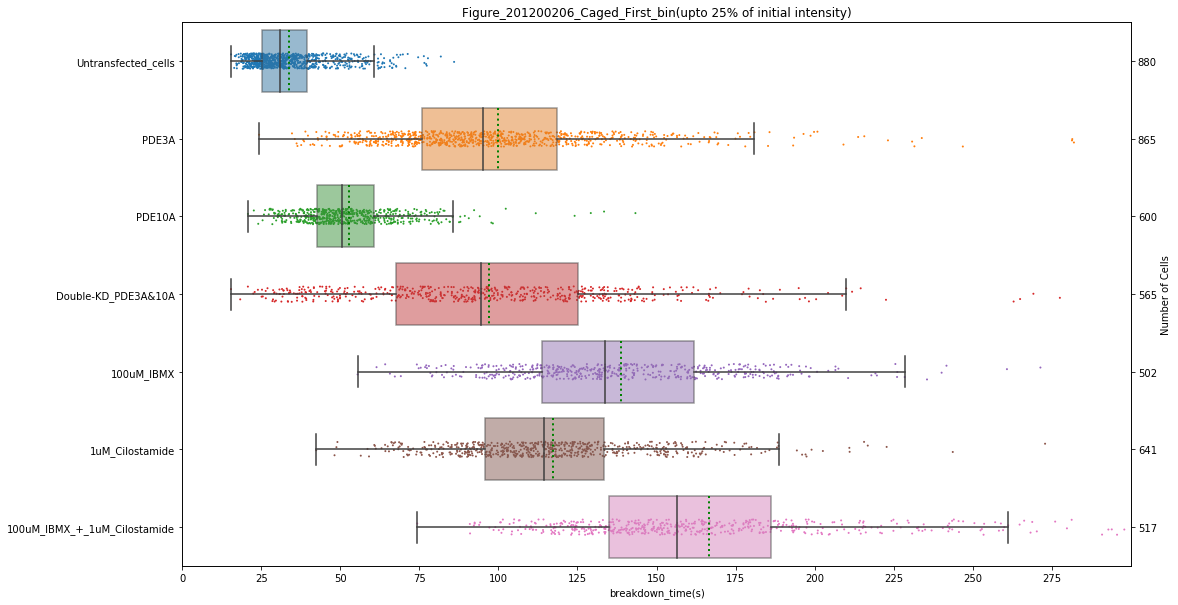

In [48]:
title = 'Figure_201200206_Caged_First_bin(upto 25% of initial intensity)' # <<<<<<< RENAME HERE EACH TIME!
fig, ax = displaydata(first_bin,'breakdown_time(s)')               # <<<<<<< modify the first argument here to display the bin you want!
ax.yaxis.set_label_text("") # we loose the y-axis title "condition"
fig.set_size_inches([17, 10])
ax.set_title(title)
xaxislength = 300
plt.xlim(0, xaxislength)
plt.xticks(ticks=range(0, xaxislength, 25))
print(users_path)

In [49]:
fig.savefig(Path('C:\\Users\\thinkBookUser\\Desktop\\Detailed comparison for initial intensities', title +'.png'),dpi=600)
#fig.savefig(Path(users_path.parent, title +'.png'),dpi=600)